In [2]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Check missing values and duplicate rows

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate Rows: 0


In [4]:
# Fill missing Postal Code values

df["Postal Code"] = df["Postal Code"].fillna(df["Postal Code"].mode()[0])

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [5]:
# Sales Summary

print("Total Sales:", df["Sales"].sum())
print("Average Sales:", df["Sales"].mean())
print("Maximum Sale:", df["Sales"].max())
print("Minimum Sale:", df["Sales"].min())

Total Sales: 2261536.7827000003
Average Sales: 230.7690594591837
Maximum Sale: 22638.48
Minimum Sale: 0.444


In [6]:
# Category-wise Sales Analysis

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print("Category-wise Total Sales:")
print(category_sales)

Category-wise Total Sales:
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


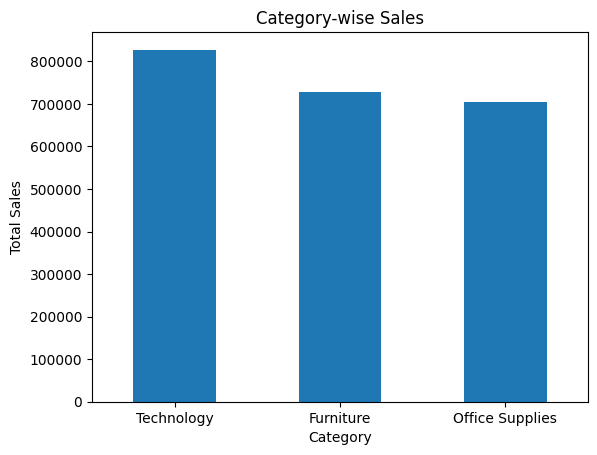

In [7]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar")

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

Region-wise Total Sales:
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


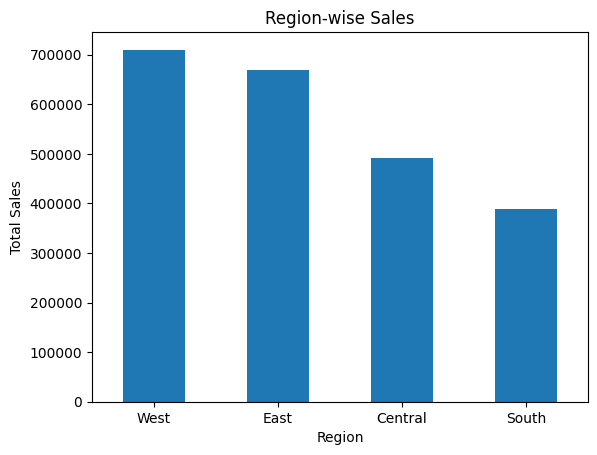

In [8]:
# Region-wise Sales Analysis

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print("Region-wise Total Sales:")
print(region_sales)

region_sales.plot(kind="bar")

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

Sub-Category-wise Total Sales:
Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


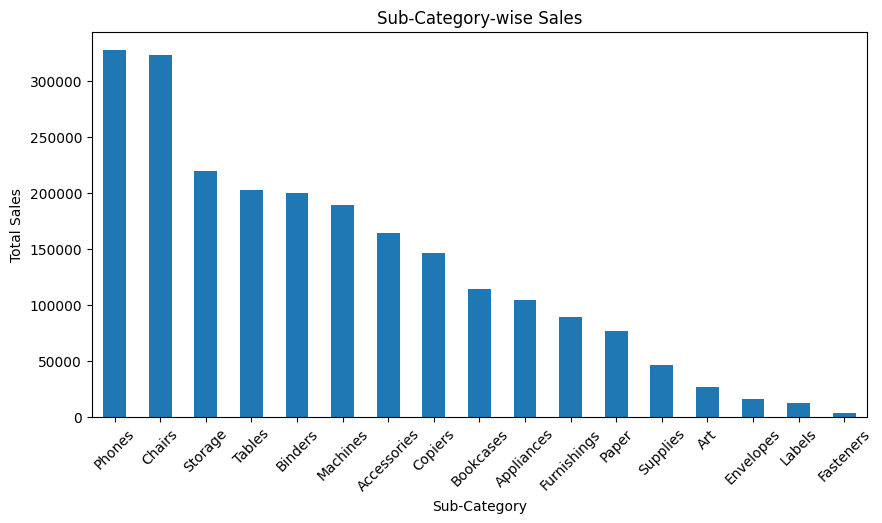

In [9]:
# Sub-Category-wise Sales Analysis

subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

print("Sub-Category-wise Total Sales:")
print(subcategory_sales)

subcategory_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Sub-Category-wise Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Segment-wise Total Sales:
Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


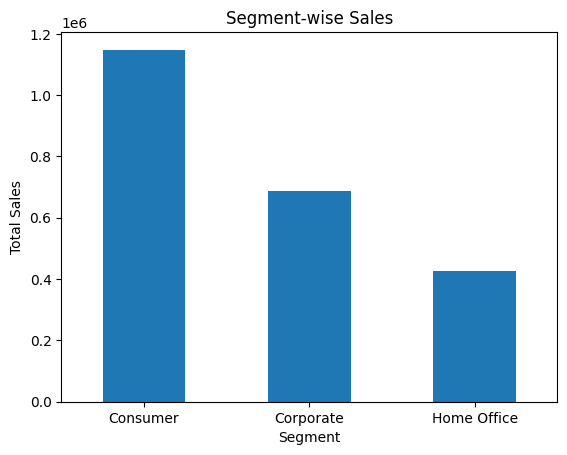

In [10]:
# Segment-wise Sales Analysis

segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

print("Segment-wise Total Sales:")
print(segment_sales)

segment_sales.plot(kind="bar")

plt.title("Segment-wise Sales")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [11]:
# Convert date columns to datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df[["Order Date", "Ship Date"]].head())
print("\nData Types:")
print(df[["Order Date", "Ship Date"]].dtypes)

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18

Data Types:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


Month-wise Sales:
Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07   

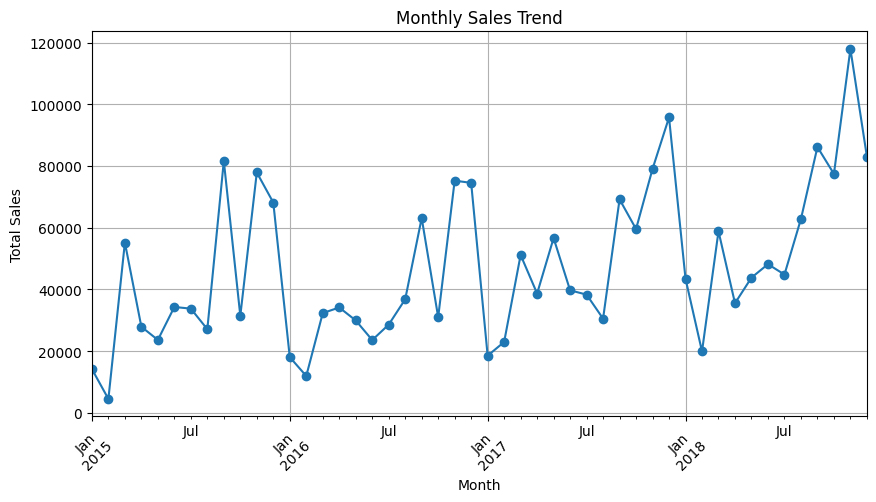

In [12]:
# Month-wise Sales Trend

df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Sales"].sum()

print("Month-wise Sales:")
print(monthly_sales)

monthly_sales.plot(kind="line", figsize=(10, 5), marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Year-wise Sales:
Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


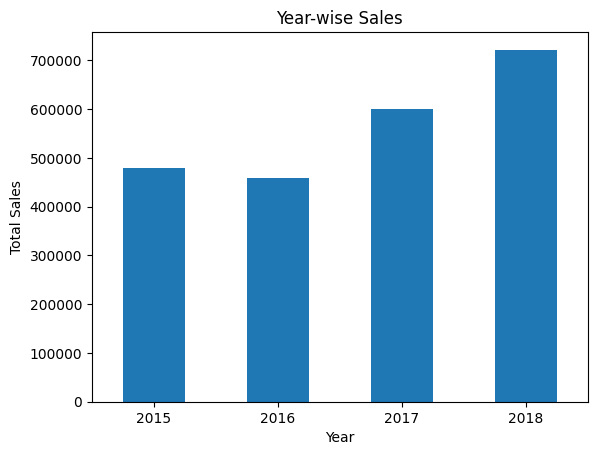

In [13]:
# Year-wise Sales Analysis

df["Year"] = df["Order Date"].dt.year

yearly_sales = df.groupby("Year")["Sales"].sum()

print("Year-wise Sales:")
print(yearly_sales)

yearly_sales.plot(kind="bar")

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


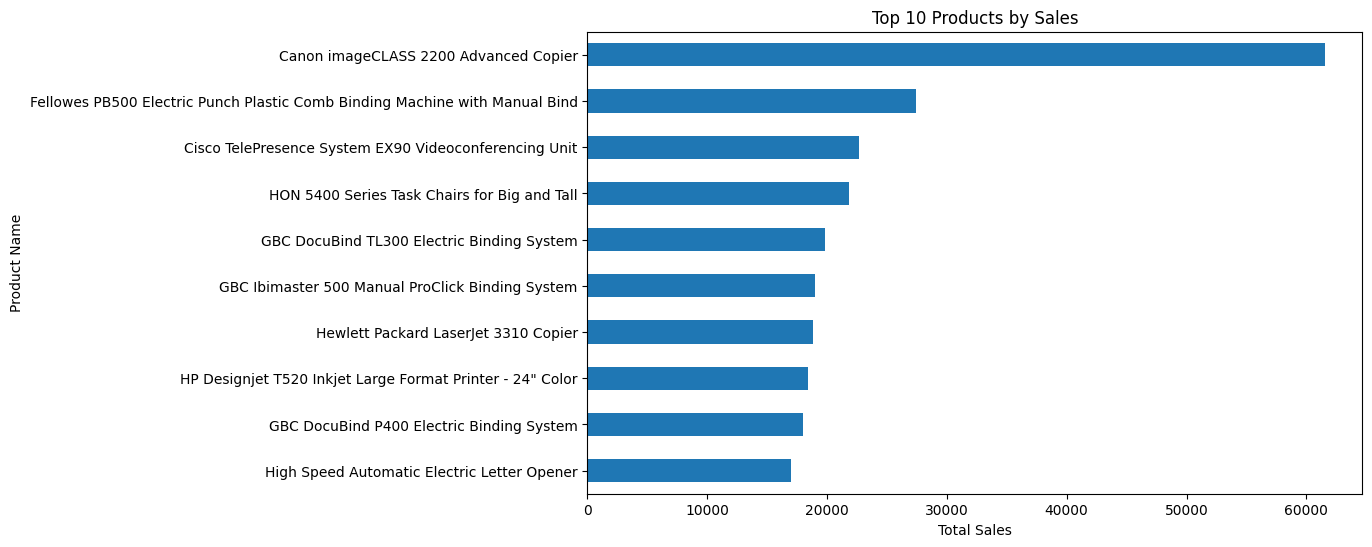

In [14]:
# Top 10 Products by Sales

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Sales:")
print(top_products)

top_products.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

Top 10 States by Sales:
State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


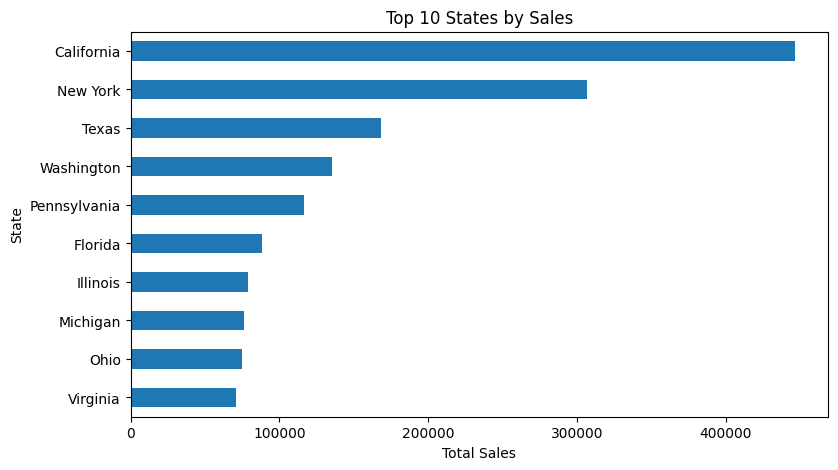

In [15]:
# Top 10 States by Sales

top_states = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 States by Sales:")
print(top_states)

top_states.sort_values().plot(kind="barh", figsize=(9, 5))

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.show()

Ship Mode-wise Sales:
Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64


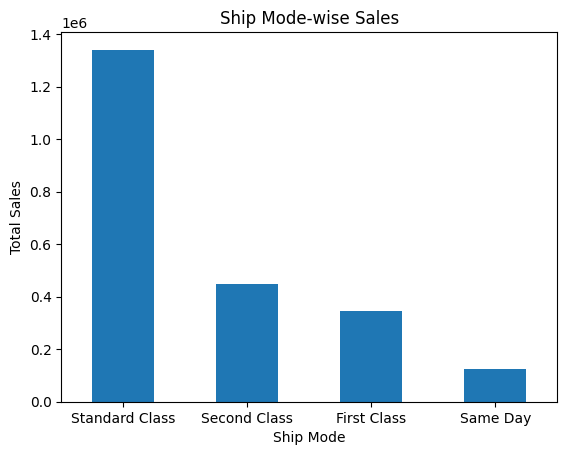

In [16]:
# Ship Mode-wise Sales Analysis

shipmode_sales = (
    df.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Ship Mode-wise Sales:")
print(shipmode_sales)

shipmode_sales.plot(kind="bar")

plt.title("Ship Mode-wise Sales")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [17]:
# Create Time Features

df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Order Date"].dt.month.apply(get_season)

print(df[["Order Date", "Year", "Month", "Week Number",
          "Day of Week", "Quarter", "Season"]].head())

  Order Date  Year    Month  Week Number Day of Week  Quarter  Season
0 2017-11-08  2017  2017-11           45   Wednesday        4  Autumn
1 2017-11-08  2017  2017-11           45   Wednesday        4  Autumn
2 2017-06-12  2017  2017-06           24      Monday        2  Summer
3 2016-10-11  2016  2016-10           41     Tuesday        4  Autumn
4 2016-10-11  2016  2016-10           41     Tuesday        4  Autumn


In [18]:
# Aggregate Sales into Weekly and Monthly Totals

daily_sales = df.groupby("Order Date")["Sales"].sum().sort_index()

weekly_sales = daily_sales.resample("W").sum()

monthly_sales_ts = daily_sales.resample("ME").sum()

print("Weekly Sales:")
print(weekly_sales.head())

print("\nMonthly Sales:")
print(monthly_sales_ts.head())

print("\nTotal Weekly Records:", len(weekly_sales))
print("Total Monthly Records:", len(monthly_sales_ts))

Weekly Sales:
Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

Monthly Sales:
Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

Total Weekly Records: 209
Total Monthly Records: 48


In [19]:
# Average Shipping Time and Region-wise Shipping Time

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Overall Average Shipping Days:")
print(round(df["Shipping Days"].mean(), 2))

print("\nAverage Shipping Days by Region:")
print(
    df.groupby("Region")["Shipping Days"]
      .mean()
      .round(2)
      .sort_values()
)

Overall Average Shipping Days:
3.96

Average Shipping Days by Region:
Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: Shipping Days, dtype: float64


In [20]:
# Region-wise Yearly Sales Growth Analysis

region_year_sales = df.groupby(["Year", "Region"])["Sales"].sum().unstack()

print("Region-wise Yearly Sales:")
print(region_year_sales)

region_growth = region_year_sales.pct_change().mean() * 100

print("\nAverage Yearly Growth Rate by Region (%):")
print(region_growth.round(2).sort_values(ascending=False))

Region-wise Yearly Sales:
Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

Average Yearly Growth Rate by Region (%):
Region
West       21.36
East       18.08
Central    12.99
South      10.62
dtype: float64


In [21]:
# Monthly Seasonality Analysis Across All Years

df["Month Number"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

monthly_seasonality = (
    df.groupby(["Year", "Month Number", "Month Name"])["Sales"]
      .sum()
      .reset_index()
)

average_monthly_sales = (
    monthly_seasonality.groupby(["Month Number", "Month Name"])["Sales"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Sales by Month Across All Years:")
print(average_monthly_sales)

Average Sales by Month Across All Years:
Month Number  Month Name
11            November      87540.427750
12            December      80370.042375
9             September     75025.852925
10            October       49874.073675
3             March         49393.396800
8             August        39328.981750
5             May           38521.680925
6             June          36459.380825
7             July          36383.922250
4             April         34070.750150
1             January       23572.907400
2             February      14842.778850
Name: Sales, dtype: float64


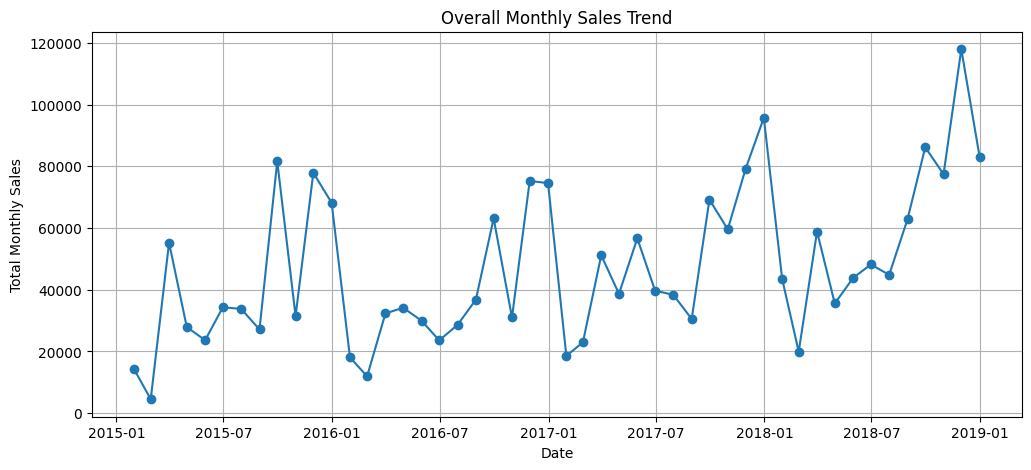

Total Months: 48


In [22]:
# Task 2: Overall Monthly Sales Trend

monthly_sales_ts = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales_ts.index, monthly_sales_ts.values, marker="o")

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Monthly Sales")
plt.grid(True)
plt.show()

print("Total Months:", len(monthly_sales_ts))

Total Monthly Records: 48
Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


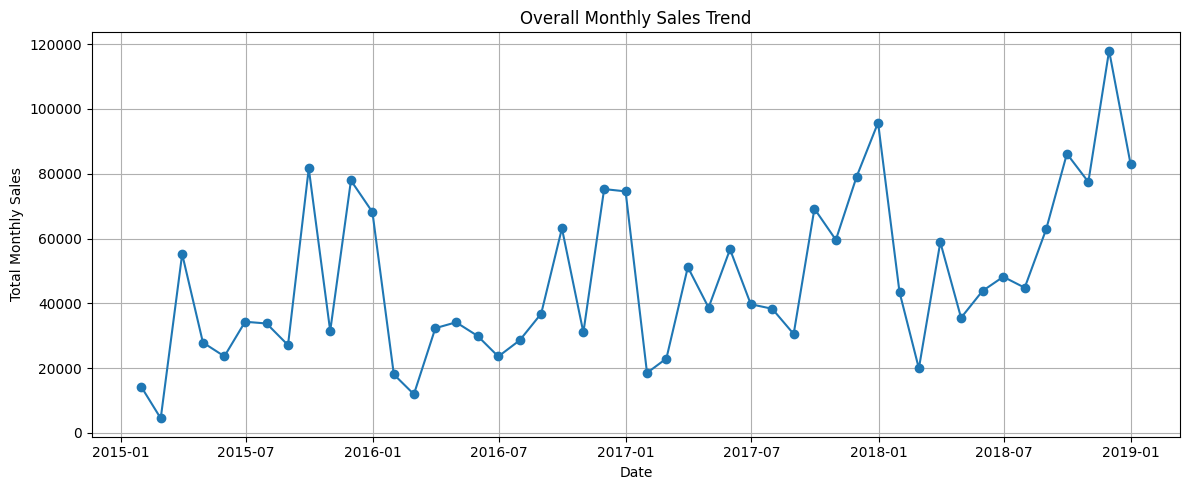

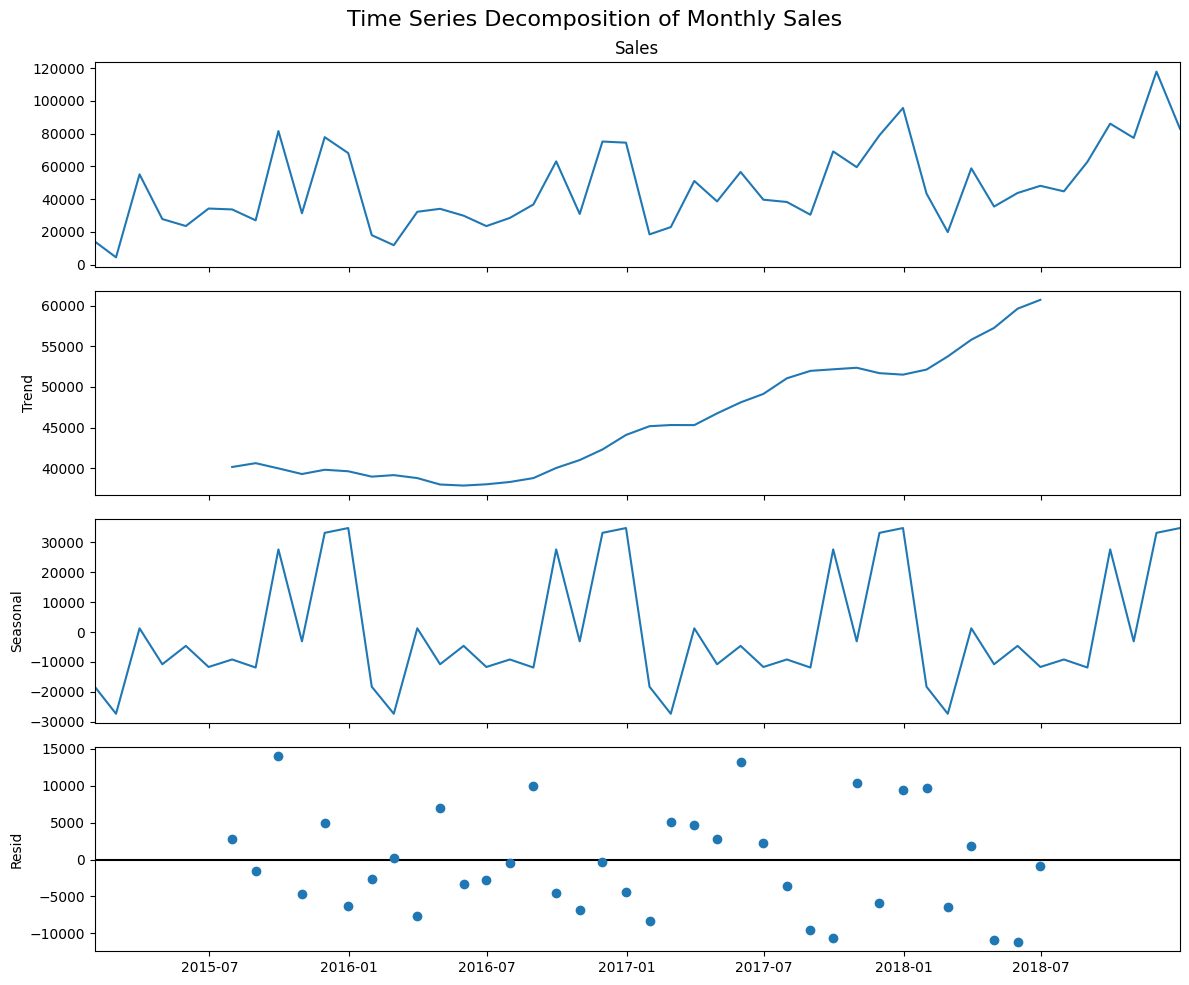


TIME SERIES OBSERVATIONS
--------------------------------------------------
1. Highest sales month: November 2018
2. Lowest sales month: February 2015
3. Month with highest residual noise: September 2015
4. The decomposition chart separates the sales data into trend, seasonal pattern, and unexplained noise.

ADF TEST — Original Monthly Sales
--------------------------------------------------
ADF Statistic: -4.4161
P-value: 0.0003
Result: The series is STATIONARY.
Meaning: Its statistical behaviour is stable enough for time-series modelling.

Differencing is not required because the original series is already stationary.

TASK 2 COMPLETED SUCCESSFULLY


In [23]:
# ============================================================
# TASK 2 — TIME SERIES ANALYSIS & DECOMPOSITION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ------------------------------------------------------------
# 1. Create Monthly Sales Time Series
# ------------------------------------------------------------

monthly_sales_ts = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)

print("Total Monthly Records:", len(monthly_sales_ts))
print(monthly_sales_ts.head())


# ------------------------------------------------------------
# 2. Plot Overall Monthly Sales Trend
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts.values,
    marker="o"
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Monthly Sales")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Time Series Decomposition
# ------------------------------------------------------------

decomposition = seasonal_decompose(
    monthly_sales_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 10)
fig.suptitle(
    "Time Series Decomposition of Monthly Sales",
    fontsize=16
)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Automatic Observations
# ------------------------------------------------------------

highest_month = monthly_sales_ts.idxmax()
lowest_month = monthly_sales_ts.idxmin()

residuals = decomposition.resid.dropna()
highest_noise_month = residuals.abs().idxmax()

print("\nTIME SERIES OBSERVATIONS")
print("-" * 50)

print(
    "1. Highest sales month:",
    highest_month.strftime("%B %Y")
)

print(
    "2. Lowest sales month:",
    lowest_month.strftime("%B %Y")
)

print(
    "3. Month with highest residual noise:",
    highest_noise_month.strftime("%B %Y")
)

print(
    "4. The decomposition chart separates the sales data "
    "into trend, seasonal pattern, and unexplained noise."
)


# ------------------------------------------------------------
# 5. ADF Stationarity Test
# ------------------------------------------------------------

def adf_test(series, name):

    result = adfuller(series.dropna())

    print(f"\nADF TEST — {name}")
    print("-" * 50)

    print("ADF Statistic:", round(result[0], 4))
    print("P-value:", round(result[1], 4))

    if result[1] <= 0.05:
        print(
            "Result: The series is STATIONARY."
        )
        print(
            "Meaning: Its statistical behaviour is stable "
            "enough for time-series modelling."
        )

    else:
        print(
            "Result: The series is NON-STATIONARY."
        )
        print(
            "Meaning: Trend or changing patterns are present, "
            "so differencing is required."
        )

    return result[1]


original_p_value = adf_test(
    monthly_sales_ts,
    "Original Monthly Sales"
)


# ------------------------------------------------------------
# 6. Apply Differencing if Non-Stationary
# ------------------------------------------------------------

if original_p_value > 0.05:

    differenced_sales = monthly_sales_ts.diff().dropna()

    plt.figure(figsize=(12, 5))
    plt.plot(
        differenced_sales.index,
        differenced_sales.values,
        marker="o"
    )

    plt.title("First-Differenced Monthly Sales")
    plt.xlabel("Date")
    plt.ylabel("Change in Monthly Sales")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    adf_test(
        differenced_sales,
        "Differenced Monthly Sales"
    )

else:

    print(
        "\nDifferencing is not required because "
        "the original series is already stationary."
    )


print("\nTASK 2 COMPLETED SUCCESSFULLY")

Training Months: 36
Testing Months: 12

TRAINING SARIMA MODEL...
SARIMA COMPLETED

TRAINING PROPHET MODEL...
PROPHET COMPLETED

TRAINING XGBOOST MODEL...
XGBOOST COMPLETED

MODEL PERFORMANCE COMPARISON
     Model       MAE      RMSE  MAPE (%)
0  Prophet   9839.84  14133.08     15.67
1  XGBoost  13463.88  15704.50     28.41
2   SARIMA  13930.02  16394.82     27.77

BEST PERFORMING MODEL: Prophet
The best model is selected based on the lowest RMSE value.


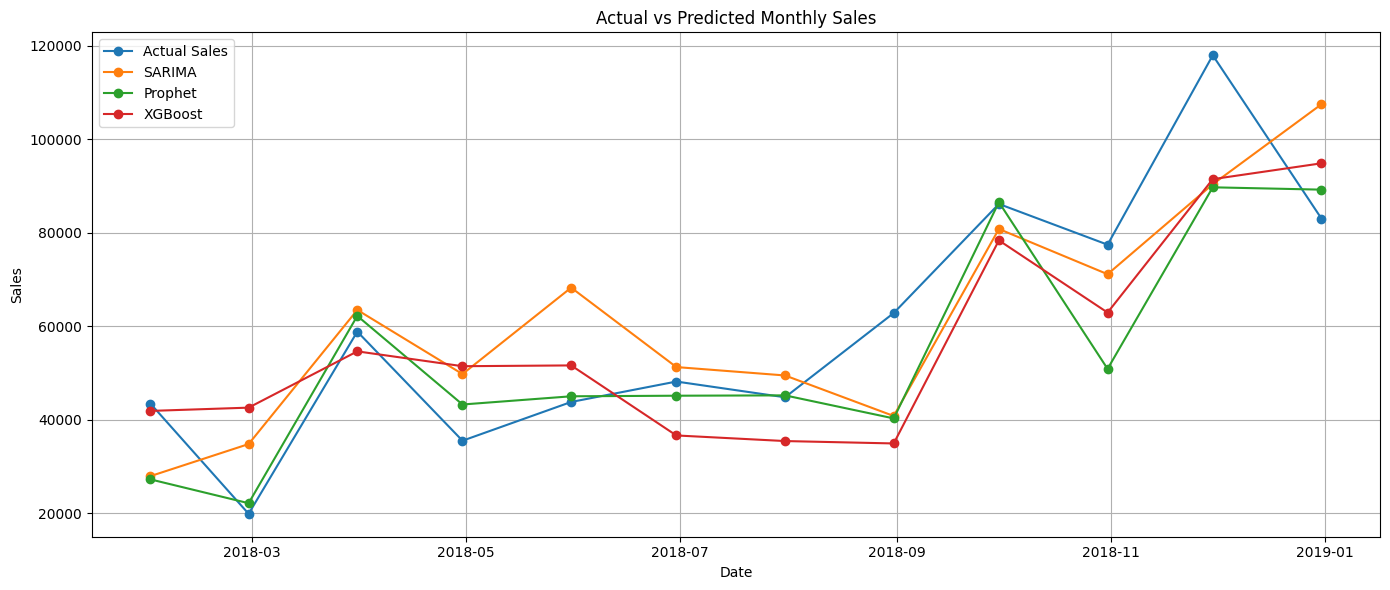

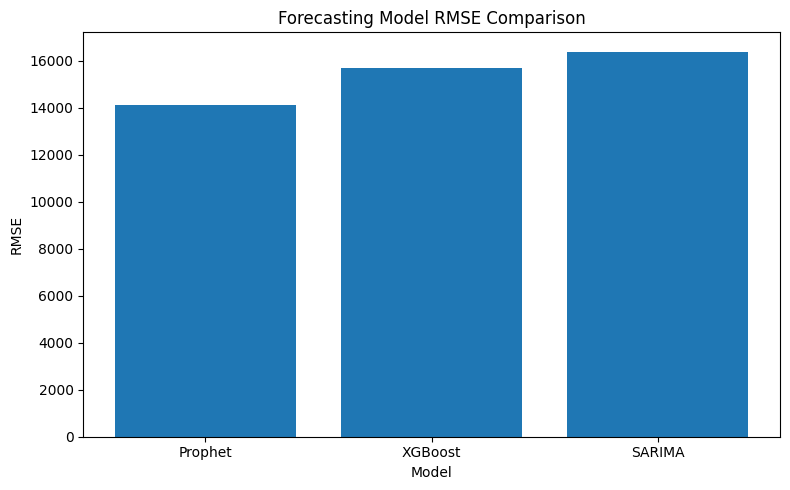


TASK 3 COMPLETED SUCCESSFULLY


In [24]:
# ============================================================
# TASK 3 — SALES FORECASTING MODELS
# SARIMA + PROPHET + XGBOOST + MODEL COMPARISON
# ============================================================

# Install Prophet and XGBoost
!pip install prophet xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor


# ------------------------------------------------------------
# 1. PREPARE MONTHLY SALES DATA
# ------------------------------------------------------------

monthly_data = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)

# Use last 12 months for testing
train = monthly_data.iloc[:-12]
test = monthly_data.iloc[-12:]

print("Training Months:", len(train))
print("Testing Months:", len(test))


# ------------------------------------------------------------
# 2. EVALUATION FUNCTION
# ------------------------------------------------------------

def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = np.mean(
        np.abs(
            (np.array(actual) - np.array(predicted))
            / np.array(actual)
        )
    ) * 100

    return mae, rmse, mape


# ============================================================
# MODEL 1 — SARIMA
# ============================================================

print("\nTRAINING SARIMA MODEL...")

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

sarima_pred = sarima_result.forecast(
    steps=len(test)
)

sarima_pred.index = test.index

sarima_mae, sarima_rmse, sarima_mape = calculate_metrics(
    test,
    sarima_pred
)

print("SARIMA COMPLETED")


# ============================================================
# MODEL 2 — PROPHET
# ============================================================

print("\nTRAINING PROPHET MODEL...")

prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(
    periods=12,
    freq="ME"
)

prophet_forecast = prophet_model.predict(future)

prophet_pred = prophet_forecast[
    "yhat"
].tail(12).values

prophet_mae, prophet_rmse, prophet_mape = calculate_metrics(
    test.values,
    prophet_pred
)

print("PROPHET COMPLETED")


# ============================================================
# MODEL 3 — XGBOOST
# ============================================================

print("\nTRAINING XGBOOST MODEL...")


# Create time-based features
def create_features(series):

    data = pd.DataFrame({
        "Sales": series
    })

    data["Month"] = data.index.month
    data["Year"] = data.index.year
    data["Quarter"] = data.index.quarter
    data["Time_Index"] = np.arange(len(data))

    return data


xgb_data = create_features(monthly_data)

xgb_train = xgb_data.iloc[:-12]
xgb_test = xgb_data.iloc[-12:]

features = [
    "Month",
    "Year",
    "Quarter",
    "Time_Index"
]

X_train = xgb_train[features]
y_train = xgb_train["Sales"]

X_test = xgb_test[features]
y_test = xgb_test["Sales"]

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_mae, xgb_rmse, xgb_mape = calculate_metrics(
    y_test,
    xgb_pred
)

print("XGBOOST COMPLETED")


# ============================================================
# 4. MODEL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE (%)": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ]
})

comparison = comparison.sort_values(
    "RMSE"
).reset_index(drop=True)

print("\nMODEL PERFORMANCE COMPARISON")
print("=" * 60)

print(
    comparison.round(2)
)


# ------------------------------------------------------------
# 5. BEST MODEL
# ------------------------------------------------------------

best_model = comparison.iloc[0]["Model"]

print("\nBEST PERFORMING MODEL:", best_model)

print(
    "The best model is selected based on "
    "the lowest RMSE value."
)


# ============================================================
# 6. ACTUAL VS PREDICTED SALES CHART
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test.index,
    sarima_pred.values,
    marker="o",
    label="SARIMA"
)

plt.plot(
    test.index,
    prophet_pred,
    marker="o",
    label="Prophet"
)

plt.plot(
    test.index,
    xgb_pred,
    marker="o",
    label="XGBoost"
)

plt.title(
    "Actual vs Predicted Monthly Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 7. MODEL RMSE COMPARISON CHART
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title(
    "Forecasting Model RMSE Comparison"
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("TASK 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

CATEGORY-WISE MONTHLY SALES
Category    Furniture  Office Supplies  Technology
Order Date                                        
2015-01-31   6217.277         4845.140    3143.290
2015-02-28   1839.658         1071.724    1608.510
2015-03-31  14243.368         8602.455   32359.974
2015-04-30   7944.837        10988.874    8973.144
2015-05-31   6912.787         7131.640    9599.876


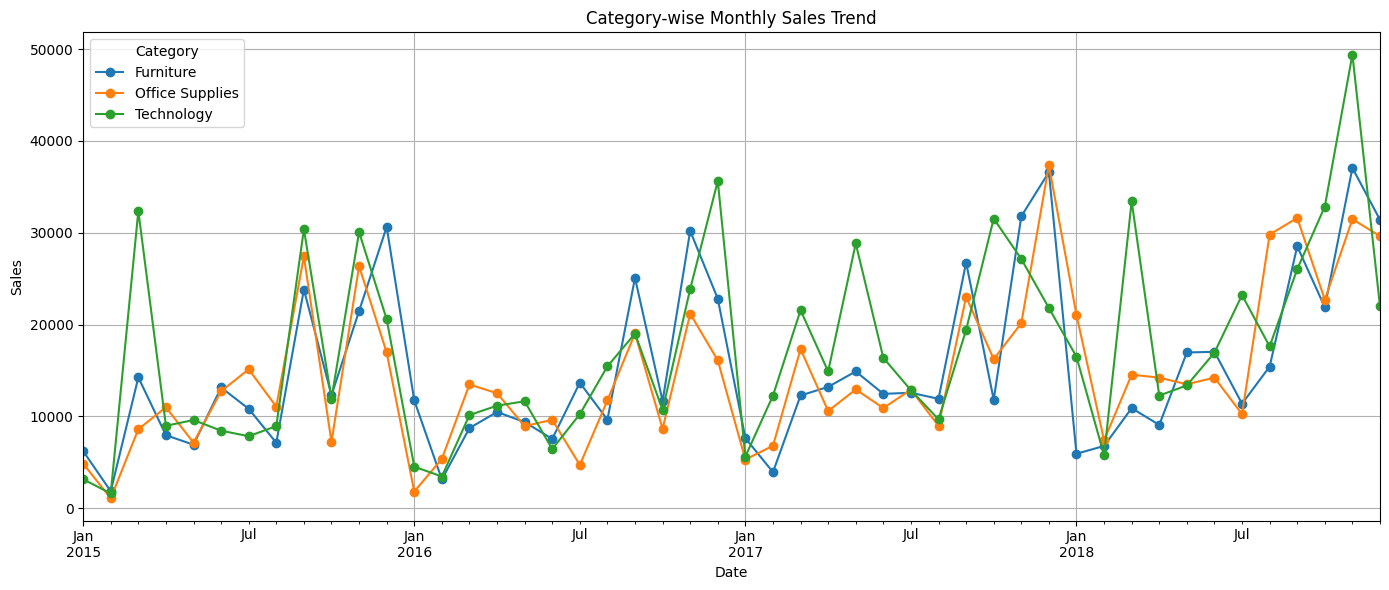


CATEGORY-WISE 12 MONTH FORECAST
            Furniture  Office Supplies  Technology
2019-01-31   10248.42         18782.08    20456.24
2019-02-28    9032.10         12655.01    13490.58
2019-03-31   14649.17         21460.90    35316.51
2019-04-30   13752.83         18116.01    18981.25
2019-05-31   19537.82         18845.55    24440.49
2019-06-30   18758.50         18273.52    22587.23
2019-07-31   15061.80         17112.04    25549.79
2019-08-31   17509.27         25594.28    20775.28
2019-09-30   31199.93         33173.85    29638.43
2019-10-31   21747.60         25275.03    38250.09
2019-11-30   38548.30         31748.94    47726.30
2019-12-31   36451.93         38881.64    27764.05


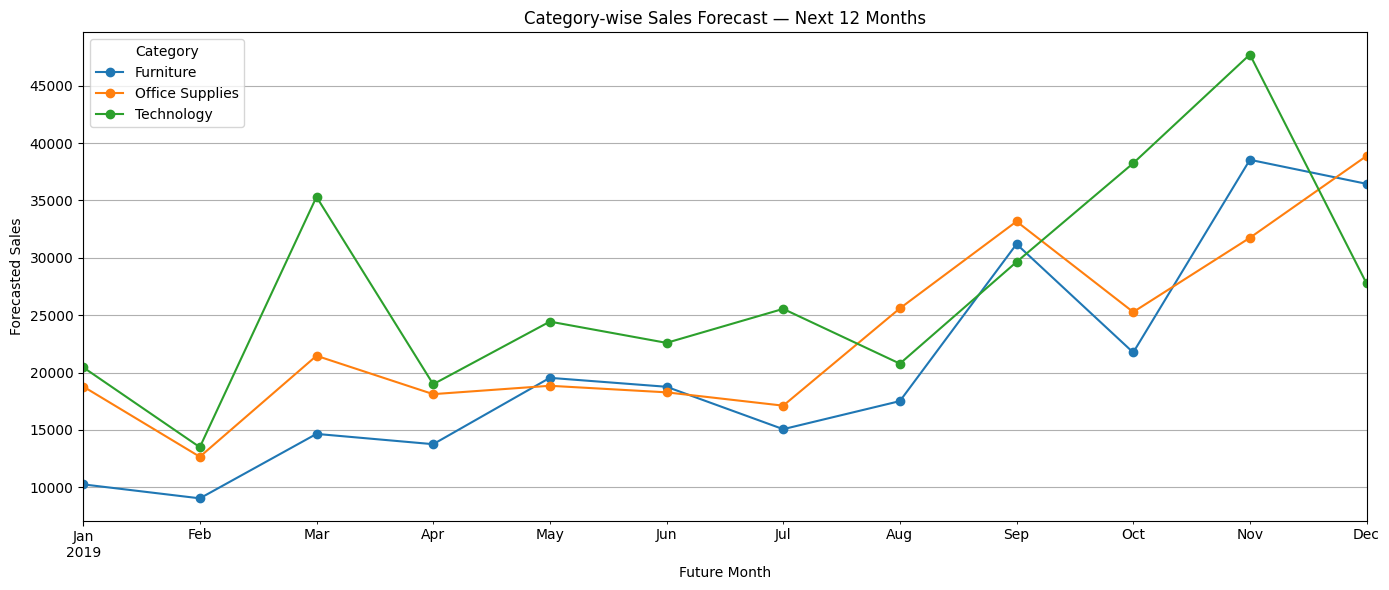


REGION-WISE MONTHLY SALES
Region       Central      East      South       West
Order Date                                          
2015-01-31  1533.966   436.174   9296.844   2938.723
2015-02-28  1233.174   199.776   2028.986   1057.956
2015-03-31  5827.602  5458.176  32911.121  11008.898
2015-04-30  3712.340  3054.906  12069.252   9070.357
2015-05-31  4044.522  7250.103   5779.240   6570.438


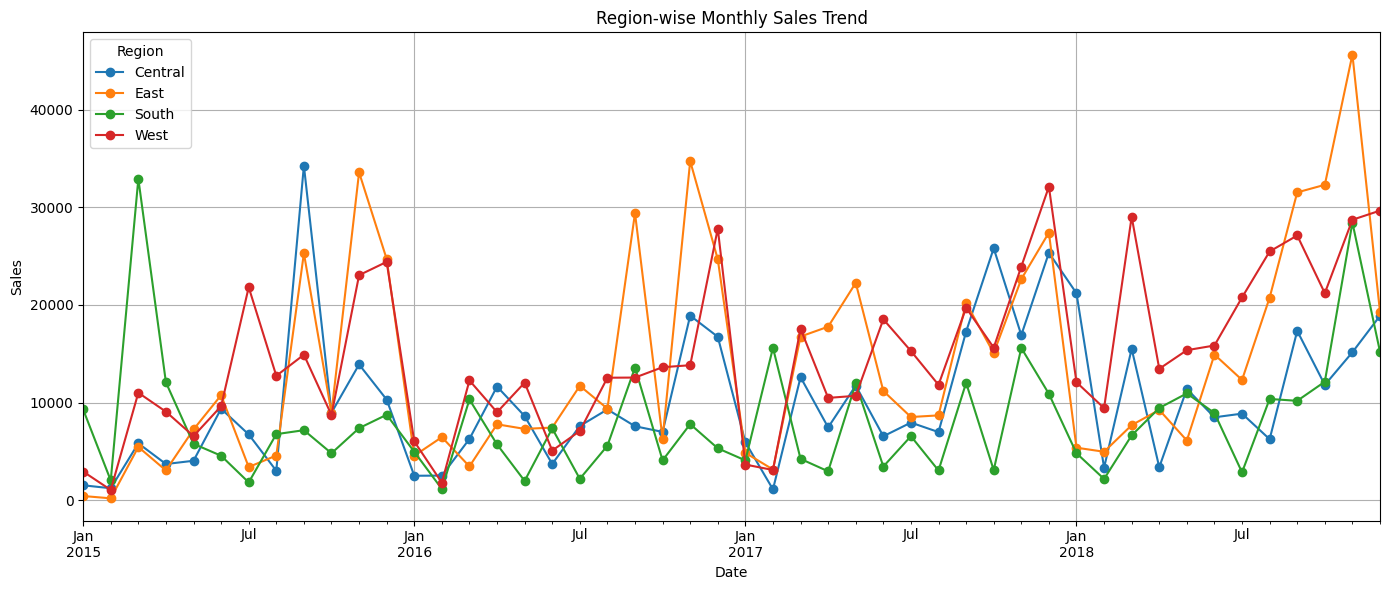


REGION-WISE 12 MONTH FORECAST
             Central      East     South      West
2019-01-31  13285.11  14400.53   7904.81  14056.39
2019-02-28   -374.67   9165.62   6941.07  12703.47
2019-03-31  11651.37  22619.58   9818.47  30217.14
2019-04-30   1896.47  23465.56  12238.11  18140.16
2019-05-31   8638.90  27277.54  14456.93  19350.95
2019-06-30   4947.56  18092.82  11819.90  22849.61
2019-07-31   5676.50  15438.10   6637.38  24417.88
2019-08-31   3623.75  16393.17  13079.35  25768.15
2019-09-30  14438.39  27830.50  13775.62  29969.46
2019-10-31  13735.74  23261.69  14678.14  24815.76
2019-11-30  12877.98  31383.69  30606.45  32652.48
2019-12-31  18218.54  33178.83  18208.26  36561.93


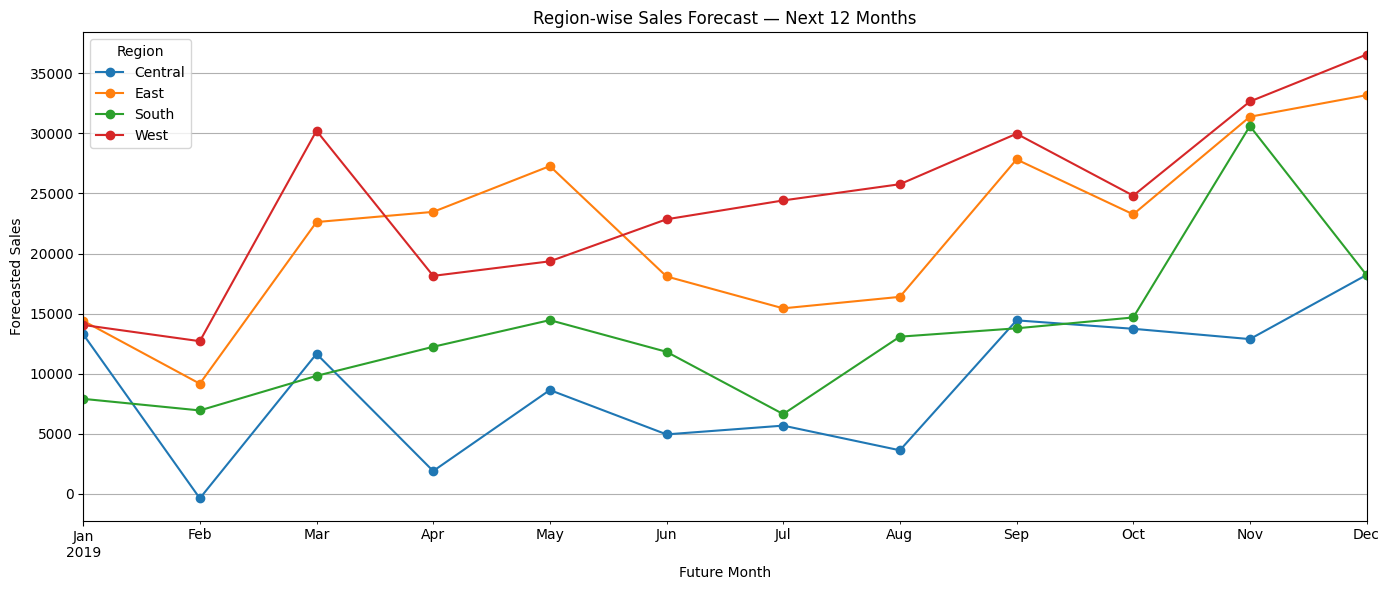


FORECAST INSIGHTS
Highest Forecasted Category: Technology
Highest Forecasted Region: West

TASK 4 COMPLETED SUCCESSFULLY


In [25]:
# ============================================================
# TASK 4 — CATEGORY & REGION WISE SALES FORECASTING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 1. CATEGORY-WISE MONTHLY SALES
# ------------------------------------------------------------

category_monthly = (
    df.groupby([
        pd.Grouper(key="Order Date", freq="ME"),
        "Category"
    ])["Sales"]
    .sum()
    .unstack()
    .fillna(0)
)

print("CATEGORY-WISE MONTHLY SALES")
print(category_monthly.head())


# ------------------------------------------------------------
# 2. CATEGORY-WISE SALES TREND
# ------------------------------------------------------------

category_monthly.plot(
    figsize=(14, 6),
    marker="o"
)

plt.title("Category-wise Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend(title="Category")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. CATEGORY-WISE 12 MONTH FORECAST
# ------------------------------------------------------------

category_forecasts = {}

for category in category_monthly.columns:

    series = category_monthly[category]

    model = SARIMAX(
        series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 0, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    forecast = result.forecast(steps=12)

    category_forecasts[category] = forecast


category_forecast_df = pd.DataFrame(
    category_forecasts
)

print("\nCATEGORY-WISE 12 MONTH FORECAST")
print(category_forecast_df.round(2))


category_forecast_df.plot(
    figsize=(14, 6),
    marker="o"
)

plt.title("Category-wise Sales Forecast — Next 12 Months")
plt.xlabel("Future Month")
plt.ylabel("Forecasted Sales")
plt.legend(title="Category")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. REGION-WISE MONTHLY SALES
# ------------------------------------------------------------

region_monthly = (
    df.groupby([
        pd.Grouper(key="Order Date", freq="ME"),
        "Region"
    ])["Sales"]
    .sum()
    .unstack()
    .fillna(0)
)

print("\nREGION-WISE MONTHLY SALES")
print(region_monthly.head())


# ------------------------------------------------------------
# 5. REGION-WISE SALES TREND
# ------------------------------------------------------------

region_monthly.plot(
    figsize=(14, 6),
    marker="o"
)

plt.title("Region-wise Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend(title="Region")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. REGION-WISE 12 MONTH FORECAST
# ------------------------------------------------------------

region_forecasts = {}

for region in region_monthly.columns:

    series = region_monthly[region]

    model = SARIMAX(
        series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 0, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    forecast = result.forecast(steps=12)

    region_forecasts[region] = forecast


region_forecast_df = pd.DataFrame(
    region_forecasts
)

print("\nREGION-WISE 12 MONTH FORECAST")
print(region_forecast_df.round(2))


region_forecast_df.plot(
    figsize=(14, 6),
    marker="o"
)

plt.title("Region-wise Sales Forecast — Next 12 Months")
plt.xlabel("Future Month")
plt.ylabel("Forecasted Sales")
plt.legend(title="Region")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. TOP FUTURE CATEGORY & REGION
# ------------------------------------------------------------

top_category = (
    category_forecast_df.sum()
    .idxmax()
)

top_region = (
    region_forecast_df.sum()
    .idxmax()
)

print("\nFORECAST INSIGHTS")
print("=" * 50)

print(
    "Highest Forecasted Category:",
    top_category
)

print(
    "Highest Forecasted Region:",
    top_region
)

print("\nTASK 4 COMPLETED SUCCESSFULLY")

Monthly Sales Data:
        Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303

DETECTED SALES ANOMALIES
         Date       Sales  Anomaly
1  2015-02-28    4519.892       -1
13 2016-02-29   11951.411       -1
35 2017-12-31   95739.121       -1
44 2018-09-30   86152.888       -1
46 2018-11-30  117938.155       -1


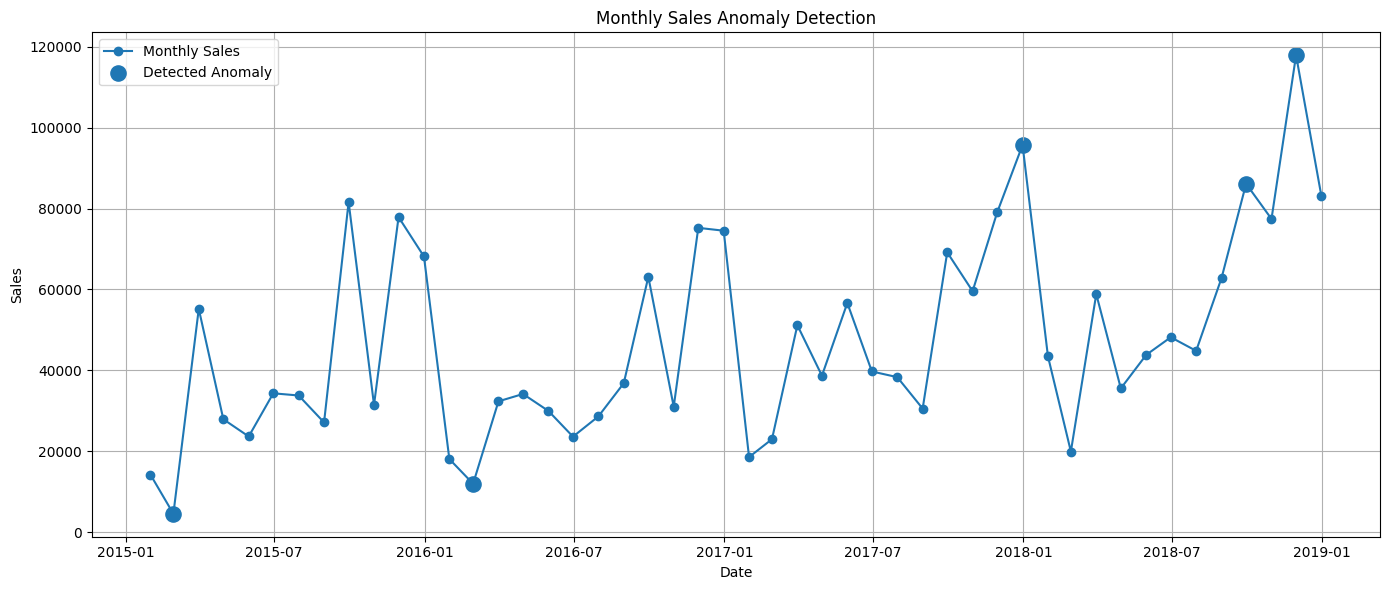


ANOMALY DETAILS
February 2015 → Sales: 4519.89
February 2016 → Sales: 11951.41
December 2017 → Sales: 95739.12
September 2018 → Sales: 86152.89
November 2018 → Sales: 117938.15

ANOMALY INSIGHTS
Highest abnormal sales month: November 2018
Lowest abnormal sales month: February 2015
Total anomalies detected: 5

Possible reasons include seasonal demand, promotional campaigns, unusual customer purchases, or unexpected drops in sales.

TASK 5 COMPLETED SUCCESSFULLY


In [26]:
# ============================================================
# TASK 5 — SALES ANOMALY DETECTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# ------------------------------------------------------------
# 1. PREPARE MONTHLY SALES DATA
# ------------------------------------------------------------

anomaly_data = monthly_sales_ts.reset_index()
anomaly_data.columns = ["Date", "Sales"]

print("Monthly Sales Data:")
print(anomaly_data.head())


# ------------------------------------------------------------
# 2. APPLY ISOLATION FOREST
# ------------------------------------------------------------

isolation_model = IsolationForest(
    contamination=0.10,
    random_state=42
)

anomaly_data["Anomaly"] = isolation_model.fit_predict(
    anomaly_data[["Sales"]]
)

# -1 = Anomaly, 1 = Normal
anomalies = anomaly_data[
    anomaly_data["Anomaly"] == -1
]

print("\nDETECTED SALES ANOMALIES")
print("=" * 50)
print(anomalies)


# ------------------------------------------------------------
# 3. VISUALIZE ANOMALIES
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    anomaly_data["Date"],
    anomaly_data["Sales"],
    marker="o",
    label="Monthly Sales"
)

plt.scatter(
    anomalies["Date"],
    anomalies["Sales"],
    s=120,
    label="Detected Anomaly"
)

plt.title("Monthly Sales Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. CALCULATE SALES CHANGE
# ------------------------------------------------------------

anomaly_data["Sales_Change_%"] = (
    anomaly_data["Sales"]
    .pct_change() * 100
)

print("\nANOMALY DETAILS")
print("=" * 50)

for _, row in anomalies.iterrows():

    print(
        row["Date"].strftime("%B %Y"),
        "→ Sales:",
        round(row["Sales"], 2)
    )


# ------------------------------------------------------------
# 5. FINAL INSIGHTS
# ------------------------------------------------------------

highest_anomaly = anomalies.loc[
    anomalies["Sales"].idxmax()
]

lowest_anomaly = anomalies.loc[
    anomalies["Sales"].idxmin()
]

print("\nANOMALY INSIGHTS")
print("=" * 50)

print(
    "Highest abnormal sales month:",
    highest_anomaly["Date"].strftime("%B %Y")
)

print(
    "Lowest abnormal sales month:",
    lowest_anomaly["Date"].strftime("%B %Y")
)

print(
    "Total anomalies detected:",
    len(anomalies)
)

print(
    "\nPossible reasons include seasonal demand, "
    "promotional campaigns, unusual customer purchases, "
    "or unexpected drops in sales."
)

print("\nTASK 5 COMPLETED SUCCESSFULLY")

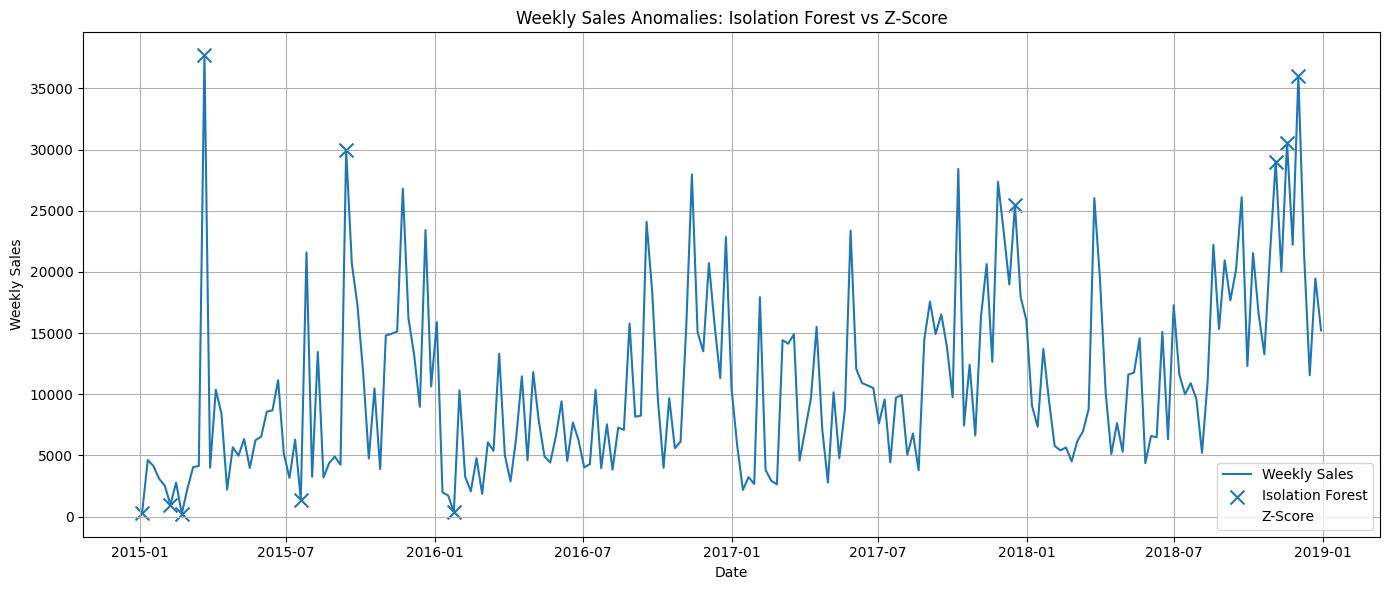

Isolation Forest Anomalies: 11
Z-Score Anomalies: 6
Common Anomalies: 1

Common Anomaly Dates:
DatetimeIndex(['2015-03-22'], dtype='datetime64[ns]', name='Order Date', freq=None)

Possible Business Explanation:
High sales anomalies may be linked to festive seasons, promotions, or bulk orders. Low anomalies may reflect seasonal slowdowns or weaker customer demand.

TASK 5 FULLY COMPLETED SUCCESSFULLY


In [27]:
# ============================================================
# TASK 5B — WEEKLY ANOMALY DETECTION + Z-SCORE COMPARISON
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Weekly sales
weekly_anomaly = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .to_frame()
)

# Method 1: Isolation Forest
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_anomaly["Isolation_Forest"] = iso_model.fit_predict(
    weekly_anomaly[["Sales"]]
)

# Method 2: Z-Score from rolling mean
weekly_anomaly["Rolling_Mean"] = (
    weekly_anomaly["Sales"].rolling(8, min_periods=4).mean()
)

weekly_anomaly["Rolling_Std"] = (
    weekly_anomaly["Sales"].rolling(8, min_periods=4).std()
)

weekly_anomaly["Z_Score"] = (
    (weekly_anomaly["Sales"] - weekly_anomaly["Rolling_Mean"])
    / weekly_anomaly["Rolling_Std"]
)

weekly_anomaly["Z_Anomaly"] = (
    weekly_anomaly["Z_Score"].abs() > 2
)

iso_anomalies = weekly_anomaly[
    weekly_anomaly["Isolation_Forest"] == -1
]

z_anomalies = weekly_anomaly[
    weekly_anomaly["Z_Anomaly"]
]

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_anomaly.index,
    weekly_anomaly["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    iso_anomalies.index,
    iso_anomalies["Sales"],
    marker="x",
    s=100,
    label="Isolation Forest"
)

plt.scatter(
    z_anomalies.index,
    z_anomalies["Sales"],
    marker="o",
    s=70,
    facecolors="none",
    label="Z-Score"
)

plt.title("Weekly Sales Anomalies: Isolation Forest vs Z-Score")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Compare methods
common_dates = iso_anomalies.index.intersection(z_anomalies.index)

print("Isolation Forest Anomalies:", len(iso_anomalies))
print("Z-Score Anomalies:", len(z_anomalies))
print("Common Anomalies:", len(common_dates))

print("\nCommon Anomaly Dates:")
print(common_dates)

print("\nPossible Business Explanation:")
print(
    "High sales anomalies may be linked to festive seasons, "
    "promotions, or bulk orders. Low anomalies may reflect "
    "seasonal slowdowns or weaker customer demand."
)

print("\nTASK 5 FULLY COMPLETED SUCCESSFULLY")

Total Products: 1893
        Product ID                                       Product Name  \
0  FUR-BO-10000112   Bush Birmingham Collection Bookcase, Dark Cherry   
1  FUR-BO-10000330  Sauder Camden County Barrister Bookcase, Plank...   
2  FUR-BO-10000362                 Sauder Inglewood Library Bookcases   
3  FUR-BO-10000468            O'Sullivan 2-Shelf Heavy-Duty Bookcases   
4  FUR-BO-10000711                          Hon Metal Bookcases, Gray   

   Total_Sales  Order_Frequency  Average_Order_Value  
0      825.174                1           825.174000  
1     1064.624                3           354.874667  
2     2154.348                5           430.869600  
3      723.842                6           120.640333  
4      851.760                2           425.880000  


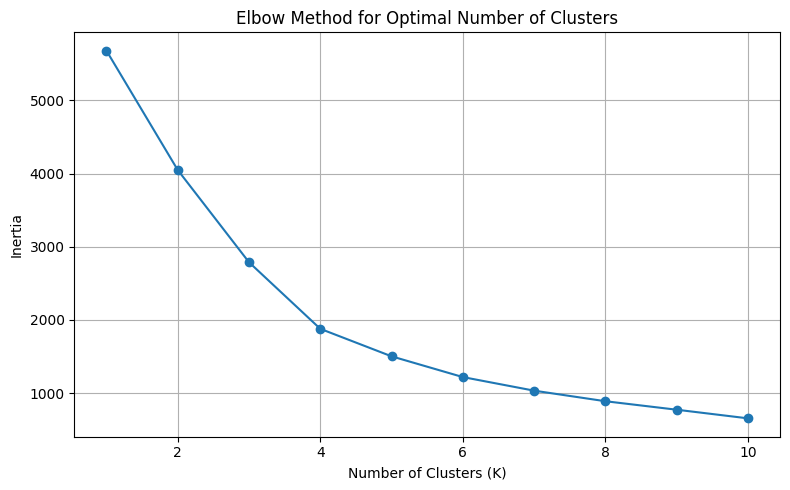


CLUSTER SUMMARY
         Total_Sales  Order_Frequency  Average_Order_Value  Number_of_Products
Cluster                                                                       
0             620.05             3.47               198.04                1090
1           16004.79             4.75              4515.13                  28
2            1467.81             7.58               197.43                 775

DEMAND SEGMENT COUNTS
Demand_Segment
Low Demand       1090
Medium Demand     775
High Demand        28
Name: count, dtype: int64


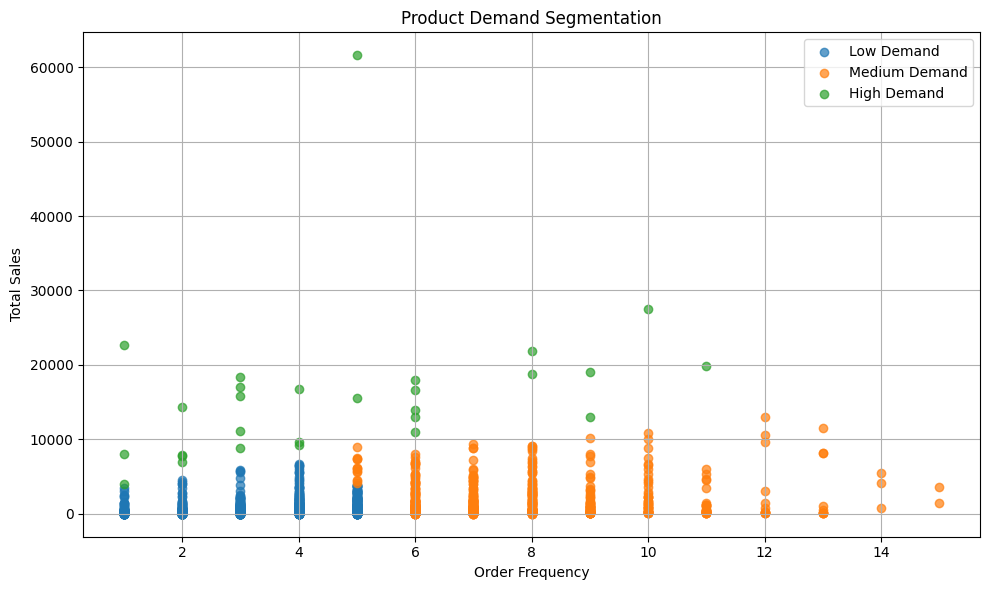


TOP 10 HIGH-DEMAND PRODUCTS
                                                               Product Name  Total_Sales  Order_Frequency  Average_Order_Value
                                      Canon imageCLASS 2200 Advanced Copier    61599.824                5         12319.964800
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384               10          2745.338400
                      Cisco TelePresence System EX90 Videoconferencing Unit    22638.480                1         22638.480000
                               HON 5400 Series Task Chairs for Big and Tall    21870.576                8          2733.822000
                                 GBC DocuBind TL300 Electric Binding System    19823.479               11          1802.134455
                           GBC Ibimaster 500 Manual ProClick Binding System    19024.500                9          2113.833333
                                       Hewlett Packard LaserJet 3310 Copier    188

In [28]:
# ============================================================
# TASK 6 — PRODUCT DEMAND SEGMENTATION USING K-MEANS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# 1. CREATE PRODUCT-LEVEL FEATURES
# ------------------------------------------------------------

product_data = (
    df.groupby(["Product ID", "Product Name"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Order_Frequency=("Order ID", "nunique"),
          Average_Order_Value=("Sales", "mean")
      )
      .reset_index()
)

print("Total Products:", len(product_data))
print(product_data.head())


# ------------------------------------------------------------
# 2. SELECT FEATURES & SCALE DATA
# ------------------------------------------------------------

features = [
    "Total_Sales",
    "Order_Frequency",
    "Average_Order_Value"
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    product_data[features]
)


# ------------------------------------------------------------
# 3. ELBOW METHOD
# ------------------------------------------------------------

inertia = []

k_values = range(1, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. APPLY K-MEANS WITH 3 CLUSTERS
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_data["Cluster"] = kmeans.fit_predict(
    scaled_features
)


# ------------------------------------------------------------
# 5. CLUSTER SUMMARY
# ------------------------------------------------------------

cluster_summary = (
    product_data.groupby("Cluster")[features]
    .mean()
    .round(2)
)

cluster_summary["Number_of_Products"] = (
    product_data["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nCLUSTER SUMMARY")
print("=" * 70)
print(cluster_summary)


# ------------------------------------------------------------
# 6. AUTOMATICALLY LABEL CLUSTERS
# ------------------------------------------------------------

cluster_sales = (
    cluster_summary["Total_Sales"]
    .sort_values()
)

low_cluster = cluster_sales.index[0]
medium_cluster = cluster_sales.index[1]
high_cluster = cluster_sales.index[2]

cluster_labels = {
    low_cluster: "Low Demand",
    medium_cluster: "Medium Demand",
    high_cluster: "High Demand"
}

product_data["Demand_Segment"] = (
    product_data["Cluster"]
    .map(cluster_labels)
)

print("\nDEMAND SEGMENT COUNTS")
print("=" * 50)
print(product_data["Demand_Segment"].value_counts())


# ------------------------------------------------------------
# 7. VISUALIZE PRODUCT SEGMENTS
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for segment in [
    "Low Demand",
    "Medium Demand",
    "High Demand"
]:

    segment_data = product_data[
        product_data["Demand_Segment"] == segment
    ]

    plt.scatter(
        segment_data["Order_Frequency"],
        segment_data["Total_Sales"],
        label=segment,
        alpha=0.7
    )

plt.title("Product Demand Segmentation")
plt.xlabel("Order Frequency")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. TOP HIGH-DEMAND PRODUCTS
# ------------------------------------------------------------

high_demand_products = (
    product_data[
        product_data["Demand_Segment"] == "High Demand"
    ]
    .sort_values(
        "Total_Sales",
        ascending=False
    )
    .head(10)
)

print("\nTOP 10 HIGH-DEMAND PRODUCTS")
print("=" * 80)

print(
    high_demand_products[
        [
            "Product Name",
            "Total_Sales",
            "Order_Frequency",
            "Average_Order_Value"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 9. BUSINESS RECOMMENDATIONS
# ------------------------------------------------------------

print("\nBUSINESS RECOMMENDATIONS")
print("=" * 60)

print(
    "1. High Demand Products: Maintain higher safety stock "
    "and avoid stock-outs."
)

print(
    "2. Medium Demand Products: Use targeted promotions "
    "to increase sales frequency."
)

print(
    "3. Low Demand Products: Reduce excess inventory and "
    "review pricing or discount strategies."
)

print(
    "4. Inventory planning should prioritize products with "
    "high sales and frequent orders."
)

print("\nTASK 6 COMPLETED SUCCESSFULLY")

In [29]:
# ============================================================
# TASK 7 — STREAMLIT INTERACTIVE DASHBOARD
# ============================================================

dashboard_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Superstore Sales Dashboard",
    layout="wide"
)

st.title("📊 Superstore Sales Forecasting Dashboard")

# Load dataset
df = pd.read_csv("train.csv")

# Convert date
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

# Sidebar filters
st.sidebar.header("Dashboard Filters")

category = st.sidebar.multiselect(
    "Select Category",
    options=df["Category"].unique(),
    default=list(df["Category"].unique())
)

region = st.sidebar.multiselect(
    "Select Region",
    options=df["Region"].unique(),
    default=list(df["Region"].unique())
)

filtered_df = df[
    (df["Category"].isin(category)) &
    (df["Region"].isin(region))
]

# KPI metrics
total_sales = filtered_df["Sales"].sum()
total_orders = filtered_df["Order ID"].nunique()
average_sales = filtered_df["Sales"].mean()

col1, col2, col3 = st.columns(3)

col1.metric(
    "Total Sales",
    f"${total_sales:,.2f}"
)

col2.metric(
    "Total Orders",
    f"{total_orders:,}"
)

col3.metric(
    "Average Sale",
    f"${average_sales:,.2f}"
)

st.divider()

# Monthly sales trend
monthly_sales = (
    filtered_df.set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

st.subheader("📈 Monthly Sales Trend")

fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Sales")
ax1.grid(True)

st.pyplot(fig1)

# Category sales
st.subheader("🛍️ Category-wise Sales")

category_sales = (
    filtered_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

st.bar_chart(category_sales)

# Region sales
st.subheader("🌍 Region-wise Sales")

region_sales = (
    filtered_df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

st.bar_chart(region_sales)

# Top products
st.subheader("🏆 Top 10 Products")

top_products = (
    filtered_df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

st.bar_chart(top_products)

st.success(
    "Dashboard loaded successfully!"
)
"""

with open("app.py", "w") as file:
    file.write(dashboard_code)

print("app.py created successfully!")
print("TASK 7 DASHBOARD FILE CREATED SUCCESSFULLY")

app.py created successfully!
TASK 7 DASHBOARD FILE CREATED SUCCESSFULLY


In [30]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 89.2 MB/s eta 0:00:00


In [31]:
!streamlit run app.py &>/content/logs.txt & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://shaky-bars-switch.loca.lt
34.71.27.167
^C


In [32]:
!pip install pyngrok -q

In [33]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print("Dashboard URL:", public_url)

ERROR:pyngrok.process.ngrok:t=2026-07-06T04:17:01+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-07-06T04:17:01+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [34]:
!streamlit run app.py --server.enableWebsocketCompression=false &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://green-snakes-fly.loca.lt
^C


In [35]:
dashboard_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Superstore Sales Dashboard",
    page_icon="📊",
    layout="wide"
)

# ---------------- LOAD DATA ----------------
@st.cache_data
def load_data():
    df = pd.read_csv("train.csv")
    df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
    df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
    return df

df = load_data()

# ---------------- TITLE ----------------
st.title("📊 Superstore Sales Forecasting Dashboard")
st.markdown("### Sales Performance & Business Insights")
st.divider()

# ---------------- KPI CARDS ----------------
total_sales = df["Sales"].sum()
avg_sales = df["Sales"].mean()
max_sale = df["Sales"].max()
total_orders = df["Order ID"].nunique()

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.markdown("### 💰 Total Sales")
    st.markdown(f"## ${total_sales:,.0f}")

with col2:
    st.markdown("### 🛒 Total Orders")
    st.markdown(f"## {total_orders:,}")

with col3:
    st.markdown("### 📈 Average Sale")
    st.markdown(f"## ${avg_sales:,.2f}")

with col4:
    st.markdown("### 🚀 Maximum Sale")
    st.markdown(f"## ${max_sale:,.2f}")

st.divider()

# ---------------- MONTHLY SALES TREND ----------------
st.header("📈 Monthly Sales Trend")

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)

fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Sales")
ax1.set_title("Monthly Sales Over Time")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
st.pyplot(fig1)
plt.close(fig1)

# ---------------- CATEGORY SALES ----------------
st.header("🛍️ Category-wise Sales")

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

fig2, ax2 = plt.subplots(figsize=(10, 5))
category_sales.plot(kind="bar", ax=ax2)
ax2.set_xlabel("Category")
ax2.set_ylabel("Sales")
ax2.set_title("Sales by Category")
ax2.tick_params(axis="x", rotation=0)
plt.tight_layout()
st.pyplot(fig2)
plt.close(fig2)

# ---------------- REGION SALES ----------------
st.header("🌍 Region-wise Sales")

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

fig3, ax3 = plt.subplots(figsize=(10, 5))
region_sales.plot(kind="bar", ax=ax3)
ax3.set_xlabel("Region")
ax3.set_ylabel("Sales")
ax3.set_title("Sales by Region")
ax3.tick_params(axis="x", rotation=0)
plt.tight_layout()
st.pyplot(fig3)
plt.close(fig3)

# ---------------- TOP 10 PRODUCTS ----------------
st.header("🏆 Top 10 Products")

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .nlargest(10)
      .sort_values()
)

fig4, ax4 = plt.subplots(figsize=(12, 7))
top_products.plot(kind="barh", ax=ax4)
ax4.set_xlabel("Sales")
ax4.set_ylabel("Product")
ax4.set_title("Top 10 Products by Sales")
plt.tight_layout()
st.pyplot(fig4)
plt.close(fig4)

# ---------------- SEGMENT SALES ----------------
st.header("👥 Segment-wise Sales")

segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

fig5, ax5 = plt.subplots(figsize=(10, 5))
segment_sales.plot(kind="bar", ax=ax5)
ax5.set_xlabel("Segment")
ax5.set_ylabel("Sales")
ax5.set_title("Sales by Customer Segment")
ax5.tick_params(axis="x", rotation=0)
plt.tight_layout()
st.pyplot(fig5)
plt.close(fig5)

# ---------------- BUSINESS INSIGHTS ----------------
st.divider()
st.header("💡 Key Business Insights")

best_category = category_sales.idxmax()
best_region = region_sales.idxmax()
best_segment = segment_sales.idxmax()
best_month = monthly_sales.idxmax().strftime("%B %Y")

st.success(f"""
🏆 Best Performing Category: {best_category}

🌍 Highest Sales Region: {best_region}

👥 Top Customer Segment: {best_segment}

📅 Highest Sales Month: {best_month}

💰 Total Sales Generated: ${total_sales:,.2f}
""")

st.success("✅ Dashboard loaded successfully!")
'''

with open("app.py", "w") as file:
    file.write(dashboard_code)

print("✅ FINAL app.py CREATED SUCCESSFULLY!")
print("🚀 Dashboard is ready!")

✅ FINAL app.py CREATED SUCCESSFULLY!
🚀 Dashboard is ready!


In [36]:
!streamlit run app.py --server.enableWebsocketCompression=false &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://green-moose-trade.loca.lt
^C
